# `subdivide_segment`, and a hand-rolled preview of grain-boundary roughening

`Polygon2d.subdivide_segment` inserts new interior points into one boundary segment,
positioned by arc-length fraction, composing on the already-tested `edit_segment` (fresh
interior `Point2d`s, endpoint identity preserved, in-place rebind) rather than
reimplementing that template.

Neither existing `MSline2d` method fits this job: `add_nodes` only accepts a point that
is *already exactly* on the polyline (zero tolerance -- not useful for inserting new
positions), and `sub_divide` is currently broken (raises on its first call -- a
pre-existing bug, not something this notebook works around).

This notebook demonstrates `subdivide_segment` directly, then uses it as the building
block for a hand-rolled "poor man's roughening" of a shared grain-boundary wall --
subdivide, then jitter each interior point via `edit_segment` -- to preview the
workflow a real `roughen_segment` API would formalise. That API is deliberately **not**
built yet (deferred: amplitude/decay model, determinism, and a not-self-intersecting
constraint are all open design questions); what's shown here is the mechanism it would
sit on top of, already working end to end.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
from shapely.geometry import Polygon as ShPolygon, MultiPolygon

from upxo.geoEntities.polygon2d_from_shapely import polygon_collection_from_shapely
from upxo.viz import gsviz

def find_shared_segment(poly_a, poly_b):
    for ia, sa in enumerate(poly_a.ring.segments):
        for ib, sb in enumerate(poly_b.ring.segments):
            if sa is sb:
                return ia, ib, sa
    return None

## 1. `subdivide_segment`, both forms

`n=` inserts that many evenly-spaced points; `at_fractions=` inserts at explicit
arc-length positions. Endpoints (junction points, possibly shared with other walls) are
never moved.

In [2]:
cells = {
    1: ShPolygon([(0, 0), (2, 0), (2, 2), (0, 2)]),
    2: ShPolygon([(2, 0), (4, 0), (4, 2), (2, 2)]),
}
result = polygon_collection_from_shapely(cells)
p1, p2 = result[1], result[2]
idx1, idx2, shared = find_shared_segment(p1, p2)
start_before, end_before = shared.nodes[0], shared.nodes[-1]

print('before:', p1.ring.segments[idx1].get_node_coords().tolist())
p1.subdivide_segment(idx1, n=4)
print('after n=4:', p1.ring.segments[idx1].get_node_coords().tolist())

# A second, independent structure to demonstrate the at_fractions= form.
result_b = polygon_collection_from_shapely({
    1: ShPolygon([(0, 0), (2, 0), (2, 2), (0, 2)]),
    2: ShPolygon([(2, 0), (4, 0), (4, 2), (2, 2)]),
})
pb1, pb2 = result_b[1], result_b[2]
idxb1, idxb2, sharedb = find_shared_segment(pb1, pb2)
pb1.subdivide_segment(idxb1, at_fractions=[0.2, 0.5, 0.9])
print('after at_fractions=[0.2,0.5,0.9]:', pb1.ring.segments[idxb1].get_node_coords().tolist())

print('\nendpoint identity preserved:',
     shared.nodes[0] is start_before, shared.nodes[-1] is end_before)
print('propagates to neighbour:',
     np.array_equal(p1.ring.segments[idx1].get_node_coords(),
                    p2.ring.segments[idx2].get_node_coords()))

before: [[2.0, 0.0], [2.0, 2.0]]
after n=4: [[2.0, 0.0], [2.0, 0.4], [2.0, 0.8], [2.0, 1.2], [2.0, 1.6], [2.0, 2.0]]
after at_fractions=[0.2,0.5,0.9]: [[2.0, 0.0], [2.0, 0.4], [2.0, 1.0], [2.0, 1.8], [2.0, 2.0]]

endpoint identity preserved: True True
propagates to neighbour: True


## 2. Hand-rolled roughening: subdivide, then jitter

Subdivide the shared wall densely, then move each interior point by a small random
perpendicular offset via `edit_segment` -- one edit, done through grain 1 only. Since
the wall is one shared `MSline2d` object, grain 2 picks up the exact same roughened
boundary automatically, with area moving between the two grains and the total
conserved.

grain 1: 4.0000 -> 4.0352
grain 2: 4.0000 -> 3.9648
total area conserved: 8.0000 -> 8.0000  (True)
neighbour boundary matches exactly, no gap: True


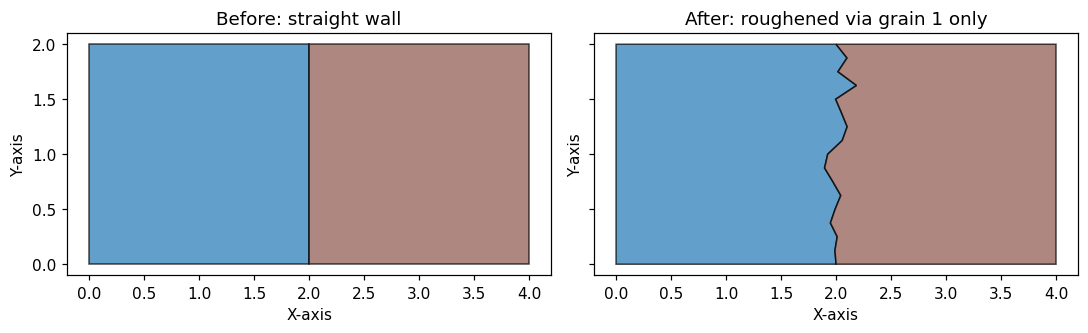

In [3]:
cells2 = {
    1: ShPolygon([(0, 0), (2, 0), (2, 2), (0, 2)]),
    2: ShPolygon([(2, 0), (4, 0), (4, 2), (2, 2)]),
}
result2 = polygon_collection_from_shapely(cells2)
g1, g2 = result2[1], result2[2]
gi1, gi2, gshared = find_shared_segment(g1, g2)

fig, axes = plt.subplots(1, 2, figsize=(10, 5), dpi=110, sharex=True, sharey=True)
gsviz.plot_multipolygon_geometric(
    MultiPolygon([g1.make_shapely(), g2.make_shapely()]), fig=fig, ax=axes[0])
axes[0].set_title('Before: straight wall')

rng = np.random.default_rng(seed=0)
g1.subdivide_segment(gi1, n=15)
coords = g1.ring.segments[gi1].get_node_coords()
tangent = coords[-1] - coords[0]
normal = np.array([-tangent[1], tangent[0]]) / np.linalg.norm(tangent)
amplitude = 0.08
new_coords = coords.copy()
for k in range(1, len(coords) - 1):
    new_coords[k] = new_coords[k] + rng.normal(0.0, amplitude) * normal
g1.edit_segment(gi1, new_coords)

gsviz.plot_multipolygon_geometric(
    MultiPolygon([g1.make_shapely(), g2.make_shapely()]), fig=fig, ax=axes[1])
axes[1].set_title('After: roughened via grain 1 only')
fig.tight_layout()

no_gap = np.array_equal(g1.ring.segments[gi1].get_node_coords(),
                        g2.ring.segments[gi2].get_node_coords())
total_before = cells2[1].area + cells2[2].area
total_after = g1.area + g2.area
print(f"grain 1: {cells2[1].area:.4f} -> {g1.area:.4f}")
print(f"grain 2: {cells2[2].area:.4f} -> {g2.area:.4f}")
print(f"total area conserved: {total_before:.4f} -> {total_after:.4f}  ({np.isclose(total_before, total_after)})")
print(f"neighbour boundary matches exactly, no gap: {no_gap}")

## 3. Zoomed-in view of the roughened wall

Both grains' rendering of the shared wall, overlaid -- they coincide exactly because
it's the same object, not two coordinate-matching copies.

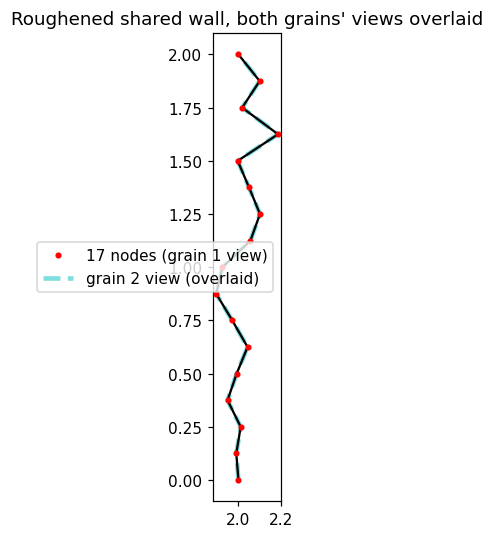

In [4]:
wall_coords = g1.ring.segments[gi1].get_node_coords()
fig, ax = plt.subplots(figsize=(4, 5), dpi=110)
ax.plot(wall_coords[:, 0], wall_coords[:, 1], 'k-', lw=1.5, zorder=3)
ax.plot(wall_coords[:, 0], wall_coords[:, 1], 'r.', ms=6, zorder=4,
       label=f'{len(wall_coords)} nodes (grain 1 view)')
wall_coords_from_b = g2.ring.segments[gi2].get_node_coords()
ax.plot(wall_coords_from_b[:, 0], wall_coords_from_b[:, 1], 'c--', lw=3, alpha=0.5,
       zorder=2, label='grain 2 view (overlaid)')
ax.set_aspect('equal')
ax.legend()
ax.set_title('Roughened shared wall, both grains\' views overlaid')
fig.tight_layout()